---
# EDA assignment 
---

#### Perform Imports

---

In [77]:
# Import necessary libraries.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import time
import keras_tuner as kt
import tensorflow as tf
import tensorflow.keras.backend as K
import os

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
LabelEncoder

from sklearn.model_selection import GridSearchCV
from scikeras.wrappers import KerasClassifier

from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam, SGD, Adagrad, RMSprop, Adadelta
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.initializers import RandomNormal
from tensorflow.keras.models import Sequential




---
#### Load DataSet

Load NZ_LUCAS_SMAO_NIWA.csv

---

In [12]:
# Read the dataset
#import os
#print(os.getcwd())
#print(os.path.exists('../data/NZ_LUCAS_SMAP_NIWA.csv'))
df = pd.read_csv("../data/NZ_LUCAS_SMAP_NIWA.csv")


#print(os.path.abspath(data_dir))

#print(os.listdir(data_dir))


In [19]:
# Data formatting for later
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)            
pd.set_option('display.max_colwidth', None)    


# Number of rows
print('Rows: ', df.shape)

df.info()


Rows:  (5000, 37)
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 37 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   latitude                         5000 non-null   float64
 1   longitude                        5000 non-null   float64
 2   elevation_m                      5000 non-null   float64
 3   slope_deg                        5000 non-null   float64
 4   aspect_deg                       5000 non-null   float64
 5   topographic_wetness_index        5000 non-null   float64
 6   terrain_ruggedness_index         5000 non-null   float64
 7   annual_rainfall_mm               5000 non-null   float64
 8   annual_temperature_c             5000 non-null   float64
 9   summer_temperature_c             5000 non-null   float64
 10  winter_temperature_c             5000 non-null   float64
 11  solar_radiation_mj               5000 non-null   float64
 12  potential_eva

In [20]:
# Display the first 5 rows
print(df.head(5))

    latitude   longitude  elevation_m  slope_deg  aspect_deg  \
0 -42.130978  171.117262    97.315825  15.660394  335.473600   
1 -34.640714  172.154664   148.801024   7.974421   38.849851   
2 -37.484079  177.109116   888.809683   9.953119  200.974535   
3 -39.217440  170.420057   394.131619   6.907954   34.959548   
4 -44.971758  177.305446   719.187523   4.219457  205.925811   

   topographic_wetness_index  terrain_ruggedness_index  annual_rainfall_mm  \
0                   7.508100                  7.365608          807.582011   
1                   7.326739                  5.683267         1179.458440   
2                  11.180950                  2.654730          943.442971   
3                   5.846627                  4.005192         1155.294725   
4                   7.425487                  9.832291         1286.631423   

   annual_temperature_c  summer_temperature_c  winter_temperature_c  \
0              9.679469             17.235948              4.557528   
1   

---
## Initial Notes

The last column  '36' is a column of blank records

The Features can be broken in to 

#### Target Variable
* soil_organic_carbon_target

#### Geographic
* Latitude
* Longitude

#### Terrain Descriptors
* elevation_m
* slope_deg
* aspect_deg
* topographic_wetness_index
* terrain_ruggedness_index

#### Climate variables
* annual_rainfall_mm
* annual_temperature_c
* summer_temperature_c
* winter_temperature_c
* solar_radiation_m
* potential_evapotranspiration_mm
* relative_humidity_pct
* frost_days_per_year
* drought_index

#### Soil Physical Properties
* clay_pct
* sand_pct
* silt_pct
* bulk density
* soil_depth_cm
* coarse_fragment_pct
* available_water_capacity_mm

#### Soil Chemical Properties
* soil_ph
* organic_nitrogen_pct
* available_phosphorus_mgkg
* exchangeable_potassium_mgkg
* cation_exchange_capacity

#### Remote Sensing Variables
* ndvi_mean
* evi_mean
* ndwi_mean
* soil_moisture_pct

#### Environmental Quality Indicators
* Environmental Quality Indicators
* climate_stress_index
* erosion_risk_index

---




---
### Check for Nulls
---

In [21]:
# Check for missing values
df.isnull().sum().sort_values(ascending=False)

36                                 5000
longitude                             0
elevation_m                           0
slope_deg                             0
latitude                              0
aspect_deg                            0
topographic_wetness_index             0
annual_rainfall_mm                    0
terrain_ruggedness_index              0
summer_temperature_c                  0
winter_temperature_c                  0
solar_radiation_mj                    0
annual_temperature_c                  0
relative_humidity_pct                 0
frost_days_per_year                   0
drought_index                         0
clay_pct                              0
sand_pct                              0
silt_pct                              0
bulk_density                          0
potential_evapotranspiration_mm       0
soil_depth_cm                         0
coarse_fragment_pct                   0
soil_ph                               0
available_water_capacity_mm           0


In [22]:
df.describe()

,latitude,longitude,elevation_m,slope_deg,aspect_deg,topographic_wetness_index,terrain_ruggedness_index,annual_rainfall_mm,annual_temperature_c,summer_temperature_c,winter_temperature_c,solar_radiation_mj,potential_evapotranspiration_mm,relative_humidity_pct,frost_days_per_year,drought_index,clay_pct,sand_pct,silt_pct,bulk_density,soil_depth_cm,coarse_fragment_pct,available_water_capacity_mm,soil_ph,organic_nitrogen_pct,available_phosphorus_mgkg,exchangeable_potassium_mgkg,cation_exchange_capacity,ndvi_mean,evi_mean,ndwi_mean,soil_moisture_pct,soil_quality_index,climate_stress_index,erosion_risk_index,soil_organic_carbon_target,36
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,0.0
mean,-40.541184,172.389333,504.696286,11.995591,178.768030,7.988307,5.008502,1208.560445,11.978216,18.007048,7.002204,15.069716,901.208516,74.852373,25.003600,0.314596,35.126828,39.367886,26.924406,1.244836,90.331215,20.285196,141.096970,6.205705,0.351100,25.021287,180.538182,17.980862,0.618753,0.496562,0.248782,32.113719,71.017943,20.755863,30.040320,63.027099,NaN
std,3.765237,3.713015,354.602398,8.321450,103.668752,2.005968,1.979305,392.354324,2.964821,3.128551,3.117561,2.959643,148.475299,10.010791,4.930725,0.236977,14.495430,17.178598,20.033445,0.149813,24.779886,11.544103,39.172355,0.782408,0.119372,10.044280,61.225668,5.997975,0.118695,0.107143,0.145561,9.789973,9.177922,10.982710,16.380964,9.645272,NaN
min,-46.999849,166.000687,3.386511,0.033139,0.001993,-0.372295,-1.393806,400.000000,4.000000,7.425280,-3.204737,8.000000,500.000000,40.000000,9.000000,0.000000,10.002623,10.035961,0.000000,0.800000,20.000000,0.001463,40.000000,4.500000,0.050000,2.000000,20.000000,3.000000,0.166220,0.106668,-0.239785,5.000000,38.841685,0.000000,0.000000,30.289095,NaN
25%,-43.829784,169.212897,245.034151,5.740084,88.885504,6.620432,3.630864,927.915620,9.928302,15.903511,4.924442,13.055253,799.009294,68.105768,22.000000,0.115401,22.498871,24.436544,10.035089,1.145862,73.578043,10.141777,114.623892,5.660080,0.272801,18.144884,137.786792,13.816697,0.538136,0.422380,0.151661,25.439275,64.815829,12.695840,18.501431,56.410138,NaN
50%,-40.499888,172.317630,423.162023,10.117302,179.714007,7.959823,4.986927,1206.284688,11.959494,18.018449,6.980685,15.089442,900.869014,74.908699,25.000000,0.293338,35.271704,39.203223,25.644018,1.247358,90.343856,20.362569,140.829872,6.200378,0.350227,24.960053,181.293576,17.901570,0.619458,0.496783,0.248332,31.898949,70.861879,20.021261,28.710494,62.974905,NaN
75%,-37.274689,175.533831,679.063317,16.223400,268.169344,9.330974,6.375344,1478.904594,13.985086,20.048785,9.090880,17.079832,1003.204166,81.782387,28.000000,0.480786,47.804467,53.947889,41.741487,1.346450,106.395557,30.291415,167.152628,6.731230,0.429223,31.594676,222.464746,22.209178,0.698464,0.569793,0.343520,38.597556,77.252864,28.520322,40.073747,69.386694,NaN
max,-34.003670,178.993568,2418.439425,45.000000,359.924174,16.597715,11.674764,2588.146732,20.000000,27.897761,18.531879,25.000000,1400.000000,100.000000,44.000000,1.229551,59.993128,69.995278,79.370229,1.800000,174.313597,39.999575,296.841438,8.500000,0.811415,64.631620,385.738197,39.411933,0.950000,0.862023,0.800000,67.233048,100.000000,65.018641,100.000000,101.456979,NaN


---

Column '36'  is completely missing values and can be dropped as it contributes no information and may add unnecessary noise

---

---

### Target  Variable Analysis

#### Histogram of 'soil_organic_carbon_target'

---

,soil_organic_carbon_target
count,5000.000000
mean,63.027099
std,9.645272
min,30.289095
25%,56.410138
50%,62.974905
75%,69.386694
max,101.456979


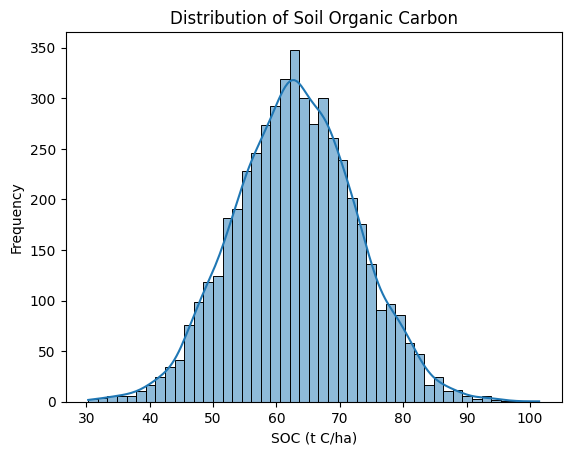

In [26]:
# Visualize the distribution of soil organic carbon
sns.histplot(
    df["soil_organic_carbon_target"],
    kde=True
)

plt.title("Distribution of Soil Organic Carbon")
plt.xlabel("SOC (t C/ha)")
plt.ylabel("Frequency")

# Display summary statistics for soil organic carbon Target
df.describe()[["soil_organic_carbon_target"]]


---

Looking at the histogram the data looks like a fairly symmetrical distribution.
From the description of the data the mean (63.03) and median (62.97) are very close. The full range Max- min is 71.167884 dividing the range by 2 then adding in to the min gives 65.873037 which is where the mean and median would be in a perfectly symetric distribution. 
The STD deviation of 9.645 is just under 10.

This all leads me to conclude that the data is reasonably symetric with few potential extreme values.

---

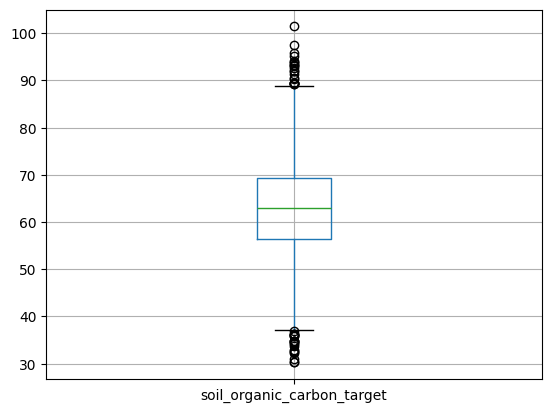

In [27]:
df.boxplot(column='soil_organic_carbon_target')
2
plt.show()

---
### Univariate Analyisis 
I have chosen:
* annual_rainfall_mm
* annual_temperature_c
* relative_humidity_pct

* clay_pct
* soil_ph
* organic_nitrogen_pct


* ndvi_mean
* evi_mean
* soil_moisture_pct


       annual_rainfall_mm
count         5000.000000
mean          1208.560445
std            392.354324
min            400.000000
25%            927.915620
50%           1206.284688
75%           1478.904594
max           2588.146732
Skewness of annual_rainfall_mm: 0.08400380637557654


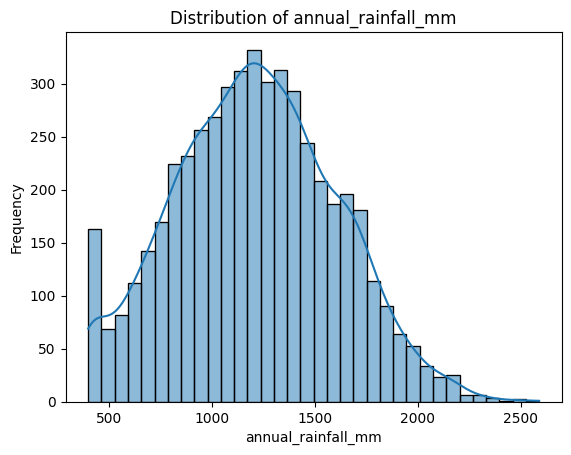

       annual_temperature_c
count           5000.000000
mean              11.978216
std                2.964821
min                4.000000
25%                9.928302
50%               11.959494
75%               13.985086
max               20.000000
Skewness of annual_temperature_c: 0.0174837366360031


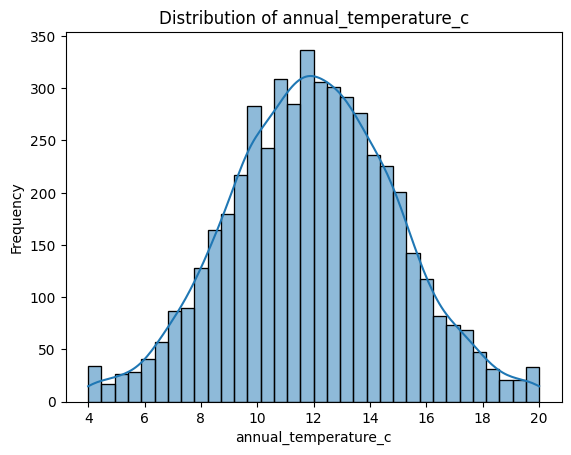

       relative_humidity_pct
count            5000.000000
mean               74.852373
std                10.010791
min                40.000000
25%                68.105768
50%                74.908699
75%                81.782387
max               100.000000
Skewness of relative_humidity_pct: -0.06398248817162792


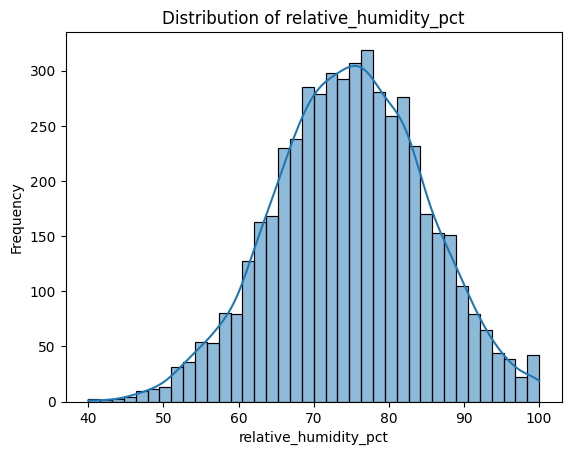

          clay_pct
count  5000.000000
mean     35.126828
std      14.495430
min      10.002623
25%      22.498871
50%      35.271704
75%      47.804467
max      59.993128
Skewness of clay_pct: -0.008663069761960716


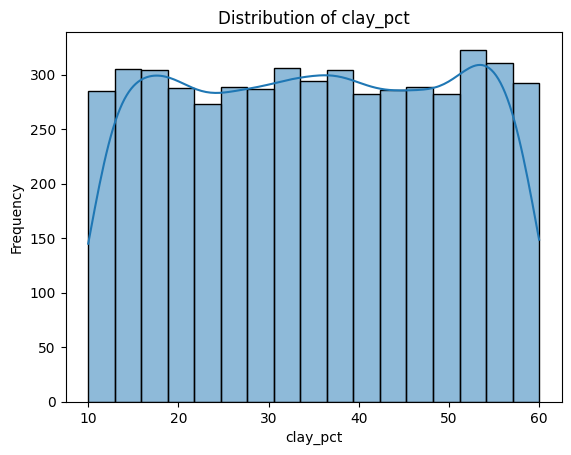

           soil_ph
count  5000.000000
mean      6.205705
std       0.782408
min       4.500000
25%       5.660080
50%       6.200378
75%       6.731230
max       8.500000
Skewness of soil_ph: 0.08414762278364302


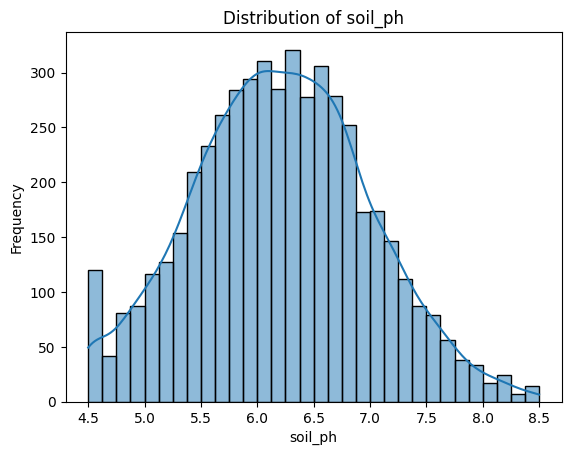

       organic_nitrogen_pct
count           5000.000000
mean               0.351100
std                0.119372
min                0.050000
25%                0.272801
50%                0.350227
75%                0.429223
max                0.811415
Skewness of organic_nitrogen_pct: 0.07374151580989007


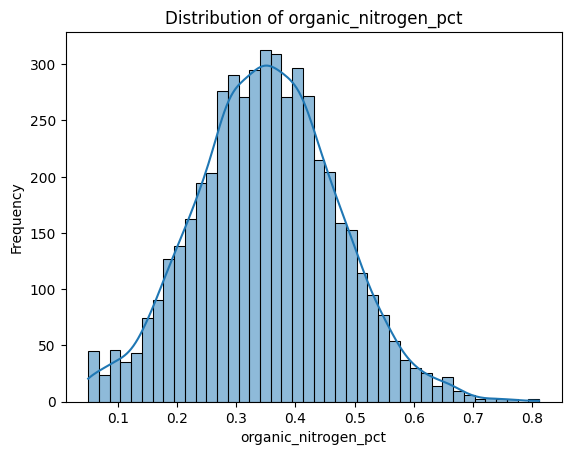

         ndvi_mean
count  5000.000000
mean      0.618753
std       0.118695
min       0.166220
25%       0.538136
50%       0.619458
75%       0.698464
max       0.950000
Skewness of ndvi_mean: -0.013127608198476023


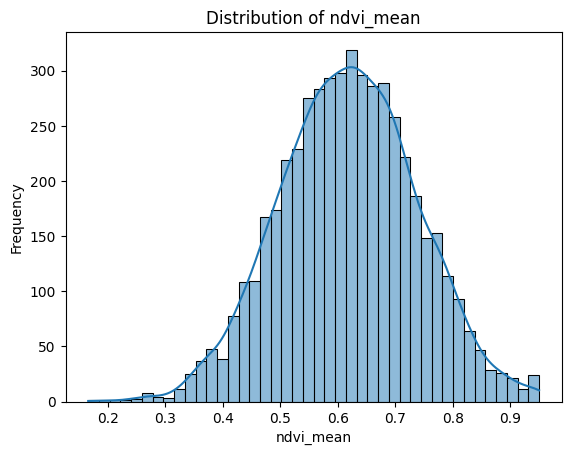

          evi_mean
count  5000.000000
mean      0.496562
std       0.107143
min       0.106668
25%       0.422380
50%       0.496783
75%       0.569793
max       0.862023
Skewness of evi_mean: -0.005745777718413927


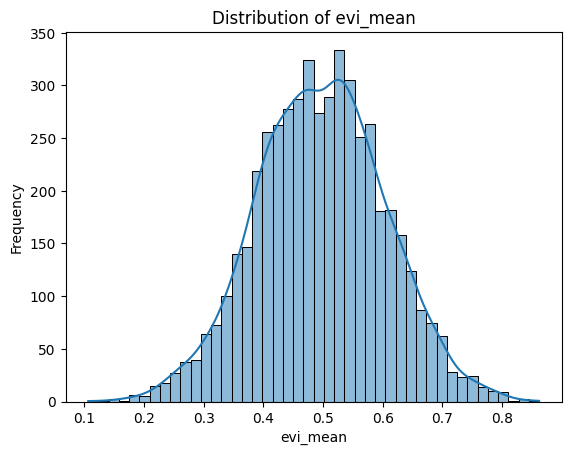

       soil_moisture_pct
count        5000.000000
mean           32.113719
std             9.789973
min             5.000000
25%            25.439275
50%            31.898949
75%            38.597556
max            67.233048
Skewness of soil_moisture_pct: 0.06938338561204414


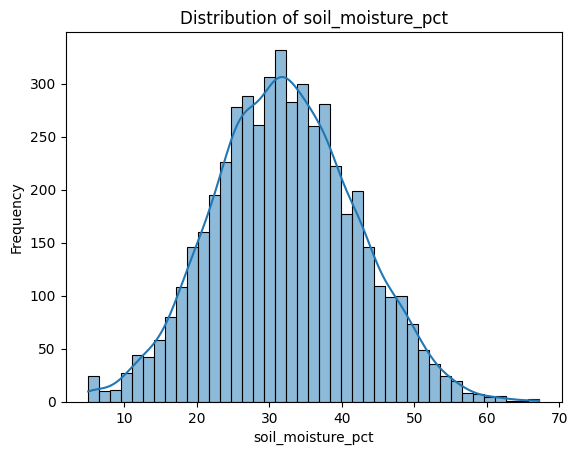

In [40]:
histograms = ['annual_rainfall_mm',
 'annual_temperature_c',
 'relative_humidity_pct',
 'clay_pct',
 'soil_ph',
 'organic_nitrogen_pct',
 'ndvi_mean',
 'evi_mean',
 'soil_moisture_pct']


for h in histograms:
    print(df.describe()[[h]])
    print(f"Skewness of {h}: {df[h].skew()}")
    sns.histplot(
        df[h],
        kde=True
    )
    plt.title(f"Distribution of {h}")
    plt.xlabel(h)
    plt.ylabel("Frequency")
    plt.show()


---
#### annual_rainfall_mm 
Annual_rainfall_mm while mean and media are fairly close there is considerable variability between locations with the min result  being heavily represented and the max results being far from the mean. with a right skew of 0.08400380637557654

#### annual_temperature_c
Annual_temperature_c has a fairly symmetrical distrbution. Small skew of 0.0174837366360031

####  relative_humidity_pct
Relative_humidity_pct has a definate left skew of -0.06398248817162792. 

#### clay_pct
Clay_pct is fairly evenly distributed with an very small skew of -0.008663069761960716. No transformation will be required.

#### soil_ph
Soil_ph has a right skew of  0.08414762278364302 with some extremmes at the lower end and has a high standard deviation.

#### organic_nitrogen_pct
Organic_nitrogen_pct  right skew of  0.07374151580989007 with some extremmes at the lower end and has a high standard deviation.


#### ndvi_mean
ndvi_mean  left skew of -0.013127608198476023 with some extremmes at the lower end and has a high standard deviation.


#### evi_mean
evi_mean had a small left skew of  -0.005745777718413927 and small standard deviation

#### soil_moisture_pct
soil_moisture_pct right skew of 0.06938338561204414 with a small standard deviation


---

---
### Outlier Analysis

annual_rainfall_mm
elevation_m
available_phosphorus_mgkg
exchangeable_potassium_mgkg
cation_exchange_capacity

---

       annual_rainfall_mm
count         5000.000000
mean          1208.560445
std            392.354324
min            400.000000
25%            927.915620
50%           1206.284688
75%           1478.904594
max           2588.146732
Skewness of annual_rainfall_mm: 0.08400380637557654


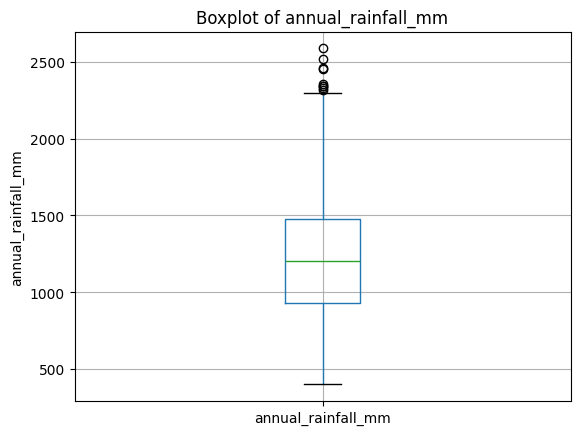

       elevation_m
count  5000.000000
mean    504.696286
std     354.602398
min       3.386511
25%     245.034151
50%     423.162023
75%     679.063317
max    2418.439425
Skewness of elevation_m: 1.3352279215995595


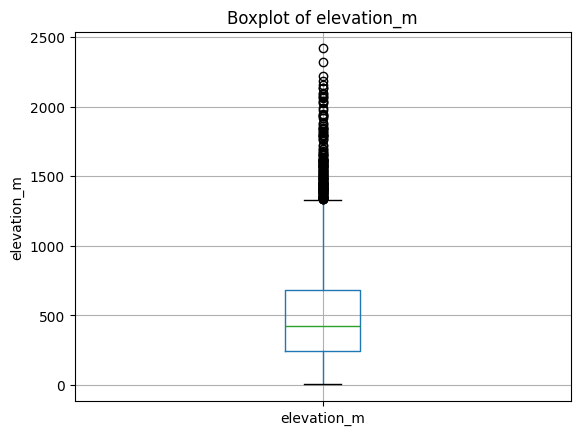

       available_phosphorus_mgkg
count                5000.000000
mean                   25.021287
std                    10.044280
min                     2.000000
25%                    18.144884
50%                    24.960053
75%                    31.594676
max                    64.631620
Skewness of available_phosphorus_mgkg: 0.11493288832905882


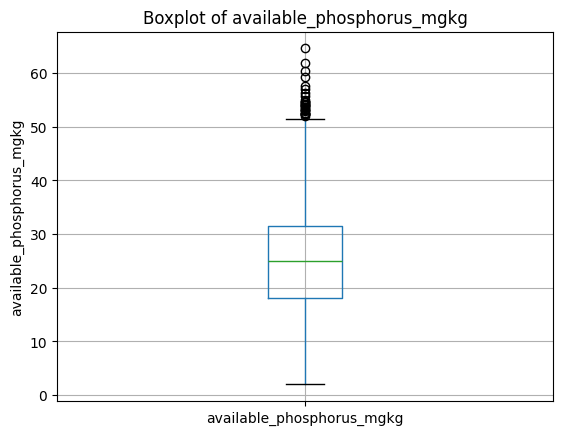

       exchangeable_potassium_mgkg
count                  5000.000000
mean                    180.538182
std                      61.225668
min                      20.000000
25%                     137.786792
50%                     181.293576
75%                     222.464746
max                     385.738197
Skewness of exchangeable_potassium_mgkg: 0.013032592273220378


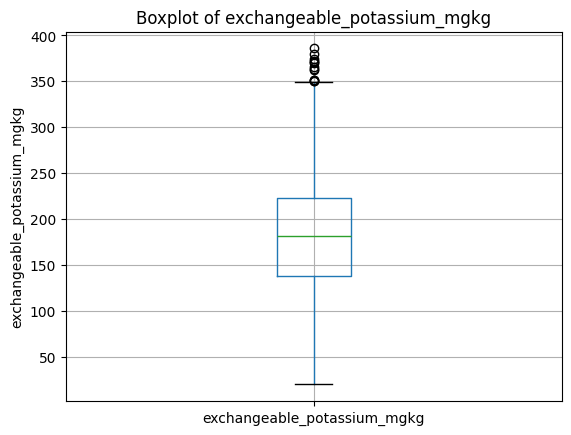

       cation_exchange_capacity
count               5000.000000
mean                  17.980862
std                    5.997975
min                    3.000000
25%                   13.816697
50%                   17.901570
75%                   22.209178
max                   39.411933
Skewness of cation_exchange_capacity: 0.029191148152580615


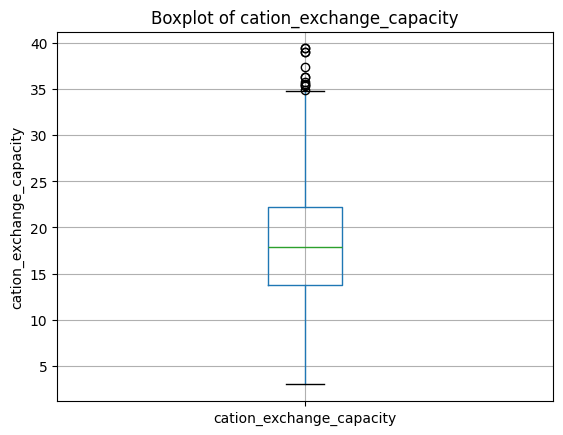

In [41]:
boxplots =['annual_rainfall_mm',
 'elevation_m',
 'available_phosphorus_mgkg',
 'exchangeable_potassium_mgkg',
 'cation_exchange_capacity'
]



for b in boxplots:
    print(df.describe()[[b]])
    print(f"Skewness of {b}: {df[b].skew()}")
    df.boxplot(column=b)
    plt.title(f"Boxplot of {b}")
    plt.ylabel(b)
    plt.show()

The nature of environmental datasets is a large probability of extreme measurements for example drought, flood, heatwaves etc. The data looked at so far looks consistent with standard enviorment extremes. 

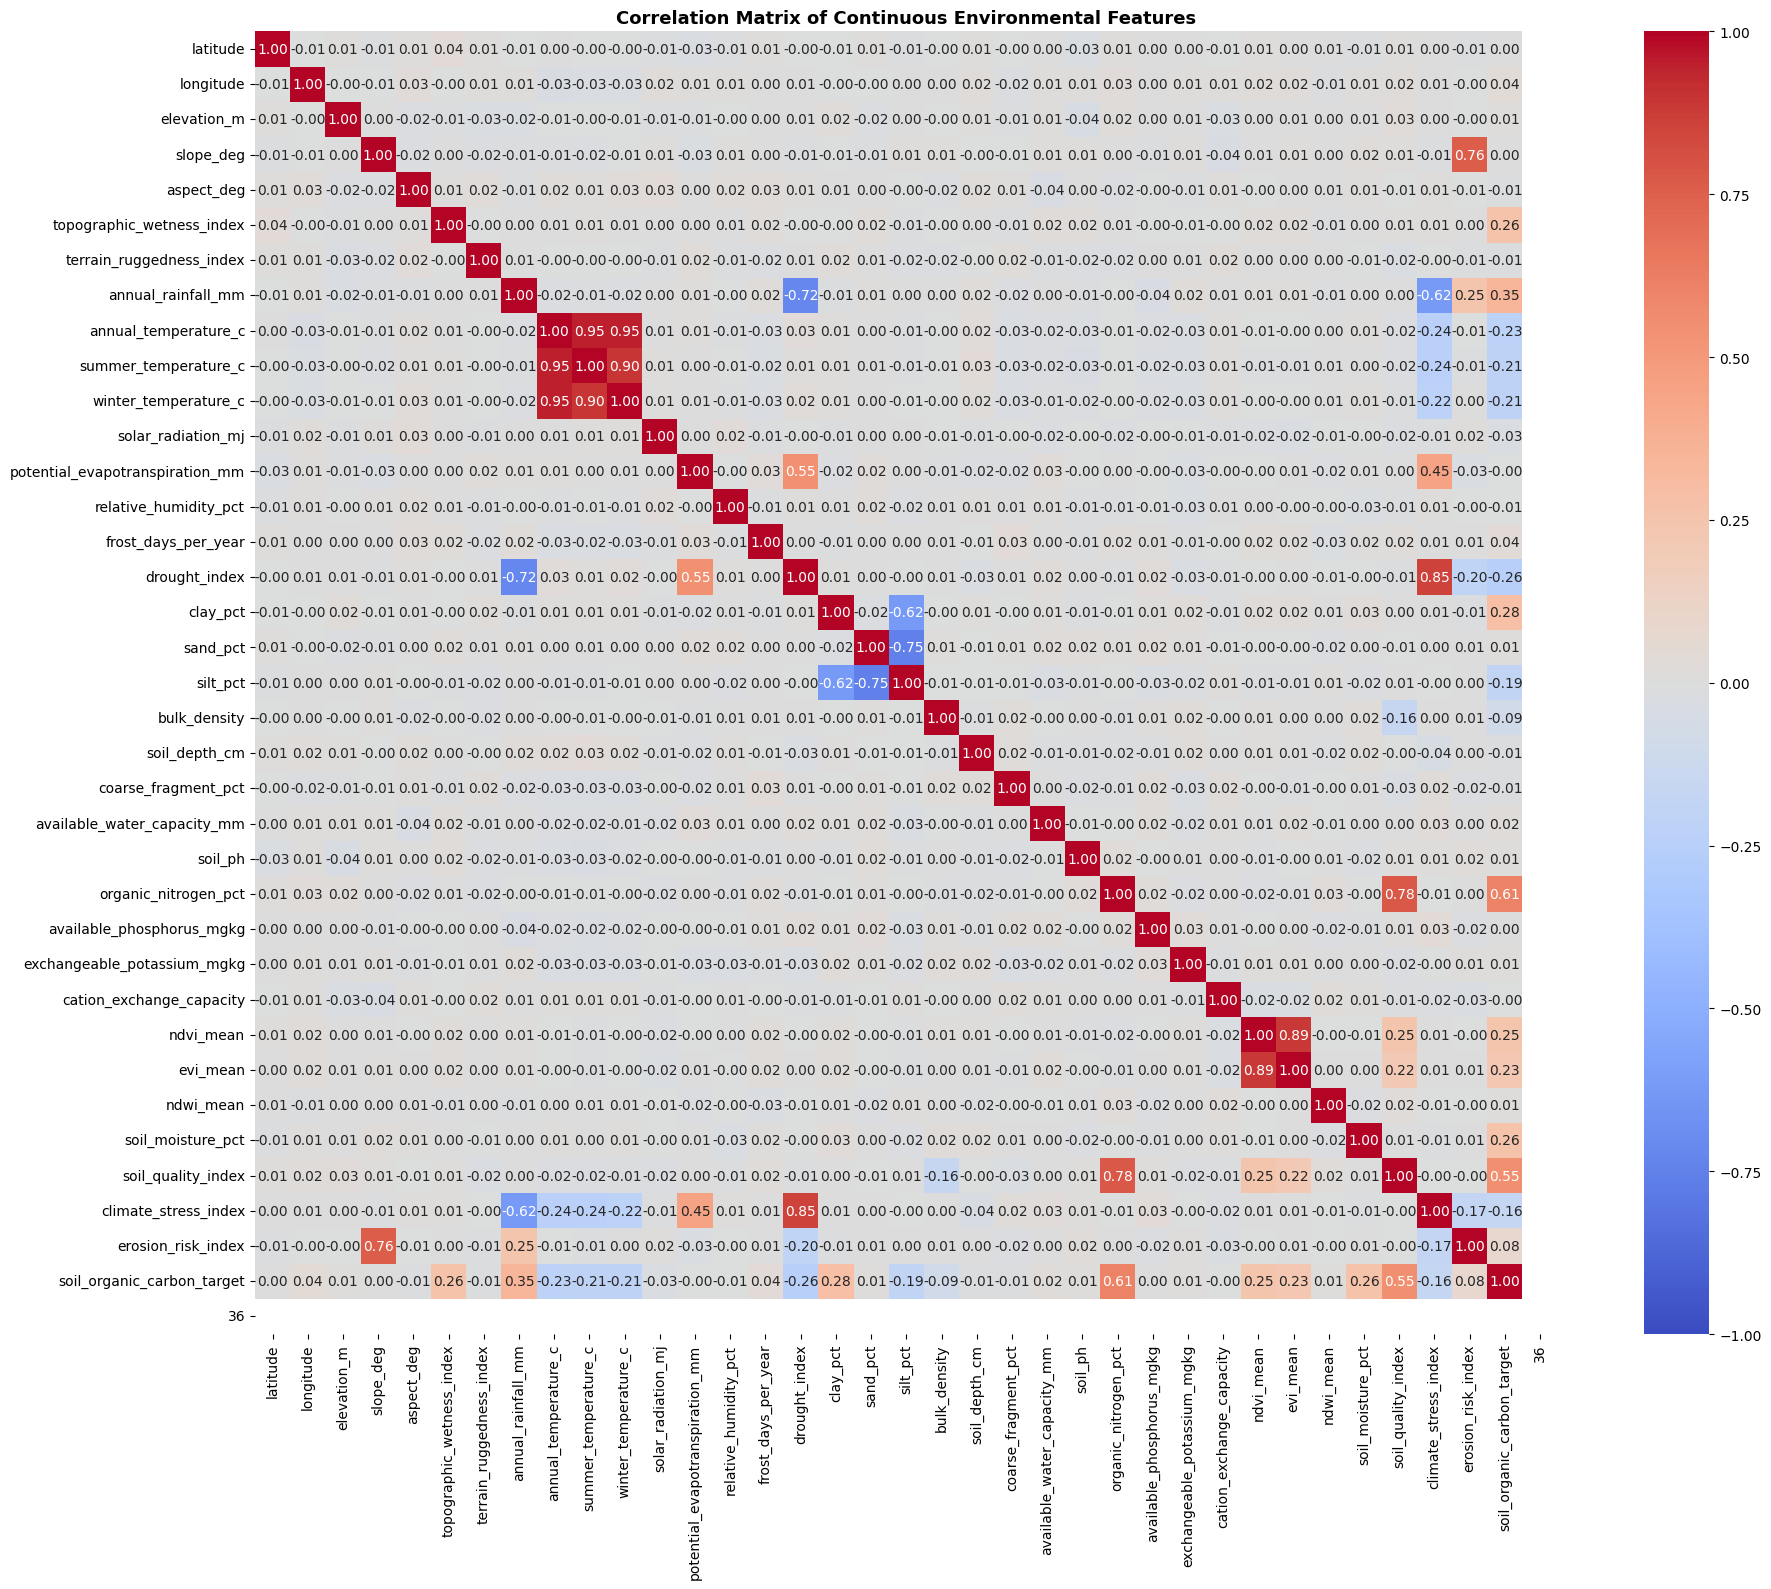

In [45]:
corr_matrix = df.corr(numeric_only=True)



plt.figure(figsize=(20,16))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Correlation Matrix of Continuous Environmental Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
#### Selected Feature Correlation Matrix

The below matrix is of the features above that had significant relationships with each other

---

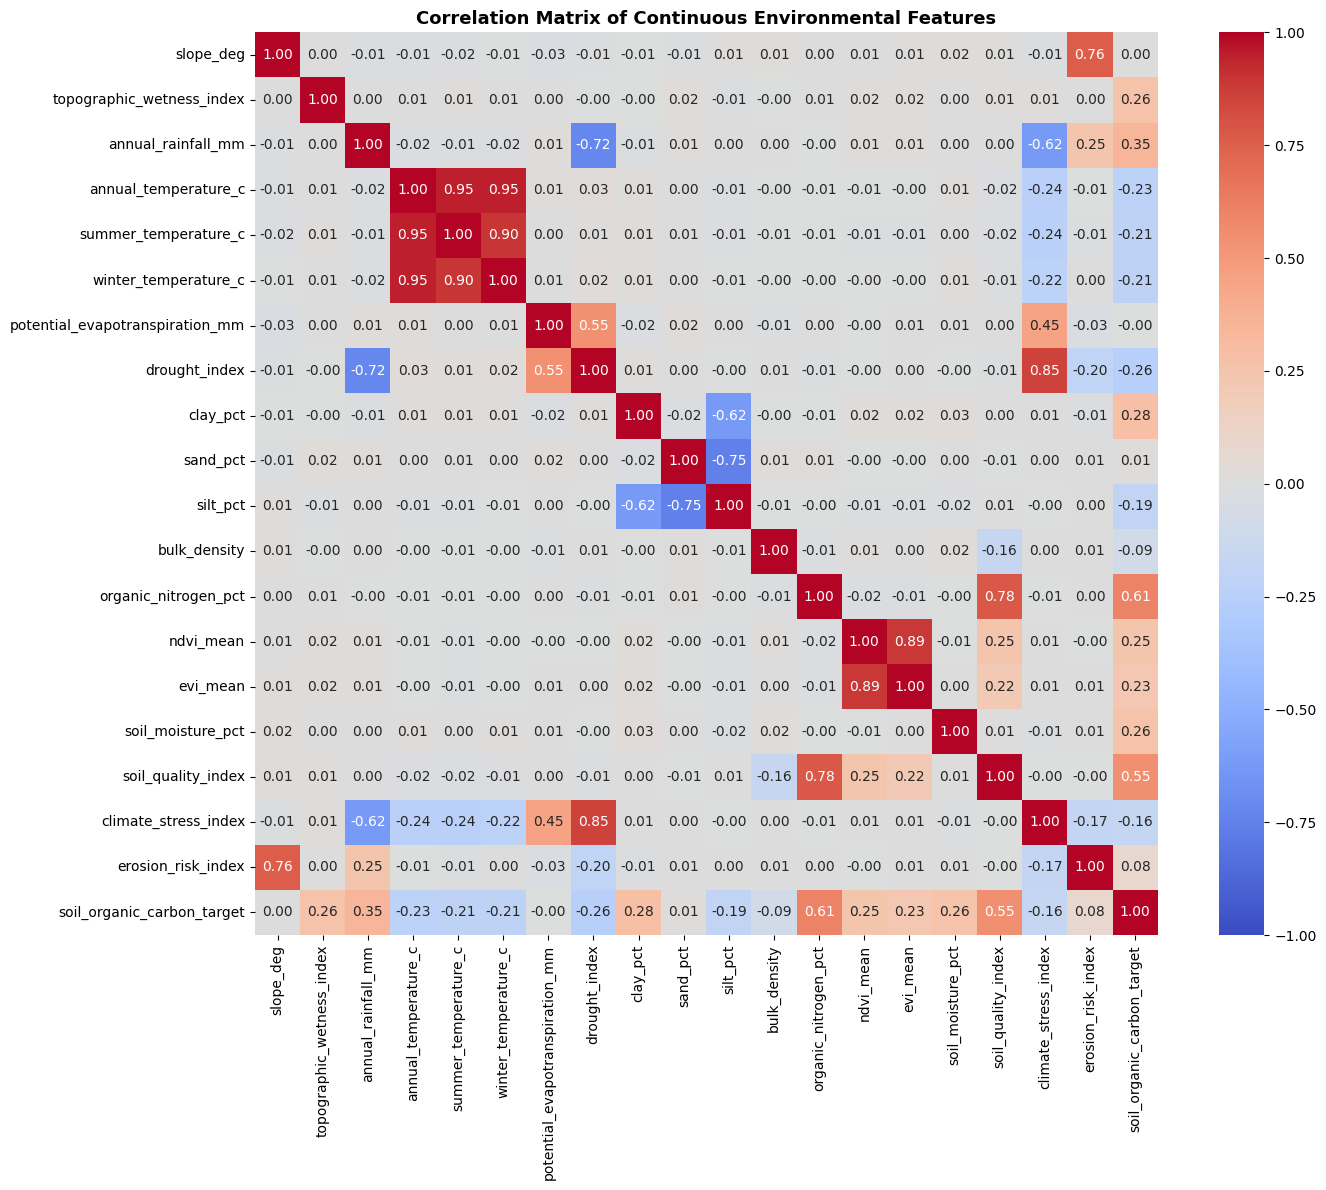

In [ ]:
#Create Correlation Matrix for Selected Features
# Setup a list of correlated features to visualize their correlation matrix
corrrelated_features = ['slope_deg',
'topographic_wetness_index',
'annual_rainfall_mm',
'annual_temperature_c',
'summer_temperature_c',
'winter_temperature_c',
'potential_evapotranspiration_mm',
'drought_index',
'clay_pct',
'sand_pct',
'silt_pct',
'bulk_density',
'organic_nitrogen_pct',
'ndvi_mean',
'evi_mean',
'soil_moisture_pct',
'soil_quality_index',
'climate_stress_index',
'erosion_risk_index',
'soil_organic_carbon_target'
]

corr_f_matrix = df[corrrelated_features].corr(numeric_only=True)

plt.figure(figsize=(15,12))     
sns.heatmap(corr_f_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Correlation Matrix of Continuous Environmental Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
### List the  correlation of the target variable with selected features
---

In [60]:
# List the  correlation of the target variable with selected features
target_corr= corr_f_matrix['soil_organic_carbon_target'].sort_values(ascending=False)

print(target_corr)


soil_organic_carbon_target         1.000000
organic_nitrogen_pct               0.606452
soil_quality_index                 0.553208
annual_rainfall_mm                 0.348765
clay_pct                           0.283623
soil_moisture_pct                  0.264877
topographic_wetness_index          0.259220
ndvi_mean                          0.245269
evi_mean                           0.227089
erosion_risk_index                 0.081103
sand_pct                           0.012057
slope_deg                          0.004802
potential_evapotranspiration_mm   -0.000404
bulk_density                      -0.088608
climate_stress_index              -0.164292
silt_pct                          -0.188958
summer_temperature_c              -0.210951
winter_temperature_c              -0.212998
annual_temperature_c              -0.225865
drought_index                     -0.256624
Name: soil_organic_carbon_target, dtype: float64


#### Correlations

---
Strongest positive correlations are:
* organic_nitrogen_pct               0.606452
* soil_quality_index                 0.553208
* annual_rainfall_mm                 0.348765
* clay_pct                           0.283623
* soil_moisture_pct                  0.264877
* topographic_wetness_index          0.259220
* ndvi_mean                          0.245269
* evi_mean                           0.227089

Strongest negative correlations are:
* summer_temperature_c              -0.210951
* winter_temperature_c              -0.212998
* annual_temperature_c              -0.225865
* drought_index                     -0.256624

This suggests that the target variable soil_organic_carbon_target (SOC) in crease in wetter enviroments (annual_rainfall_mm, soil_moisture_pct, topographic_wetness_index) and high quality soil (organic_nitrogen_pct, soil_quality_index) the density of greenery (nvvdi_mean, evi_mean) clay_pct also has a strong positive correlation with SOC.  I had assumed clay_pct would have been correlated with soil_moisture_pct and soil_quality_index  but there does not seem to be a link

---

organic_nitrogen_pct         0.369811
annual_rainfall_mm           0.119393
clay_pct                     0.085044
soil_moisture_pct            0.064421
topographic_wetness_index    0.058736
ndvi_mean                    0.043521
evi_mean                     0.022928
annual_temperature_c         0.021016
soil_quality_index           0.018996
winter_temperature_c         0.018608
dtype: float64


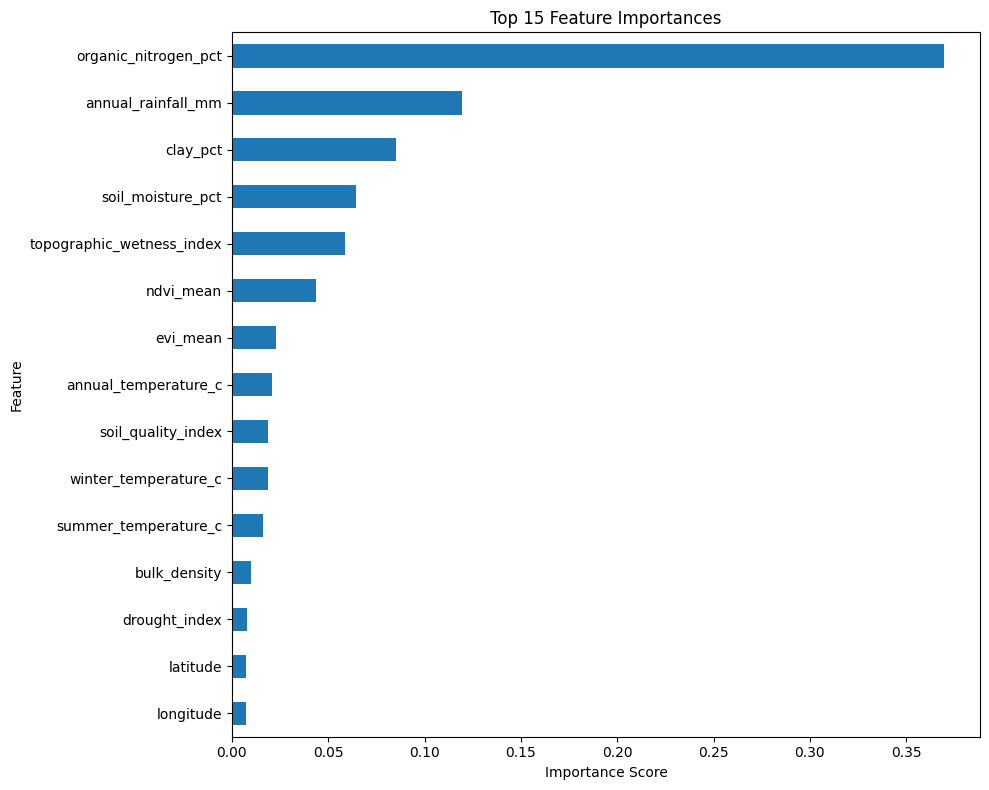

In [79]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X, y)

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance.head(10))


plt.figure(figsize=(10, 8))

importance.head(15).sort_values().plot(
    kind='barh'
)

plt.title("Top 15 Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

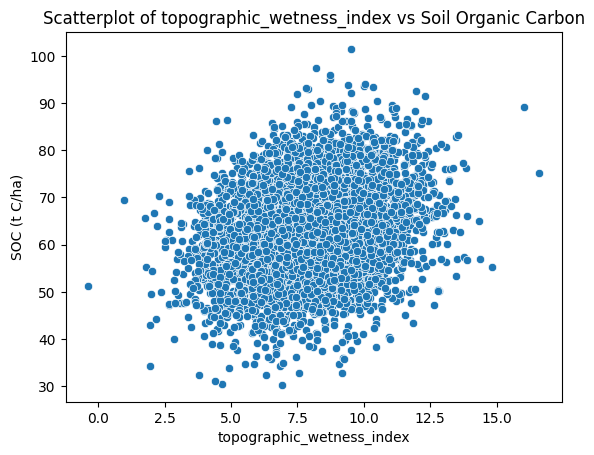

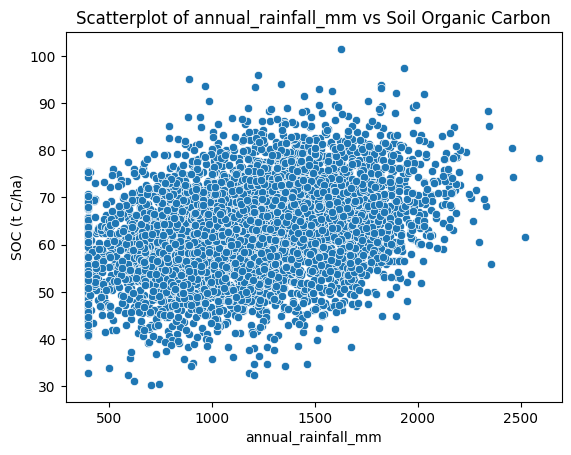

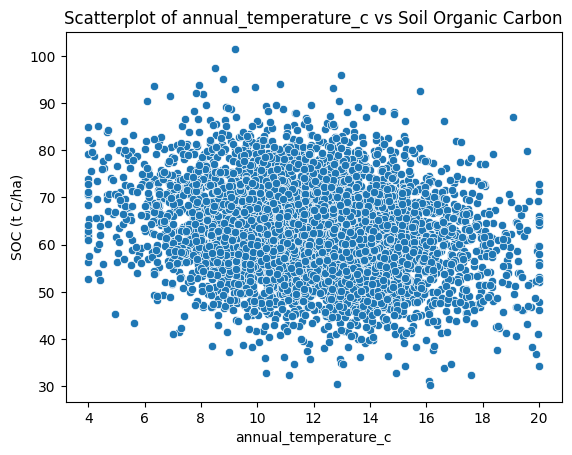

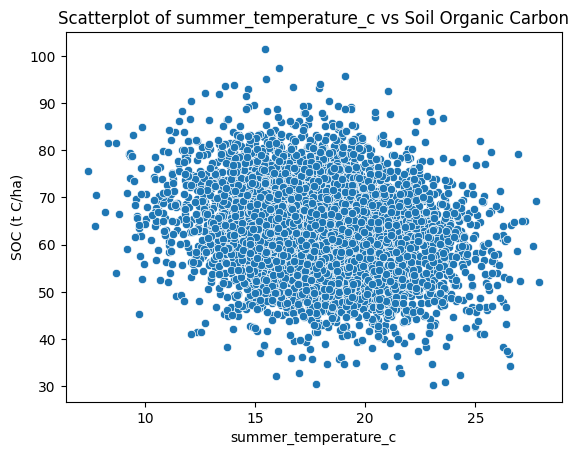

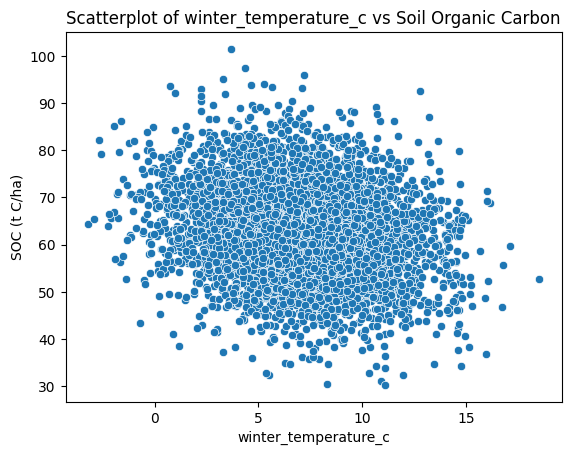

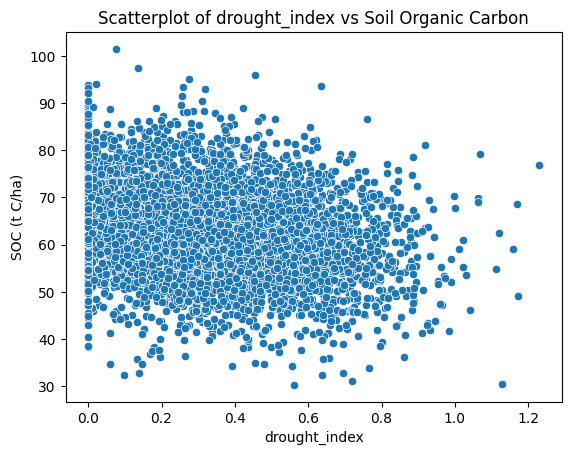

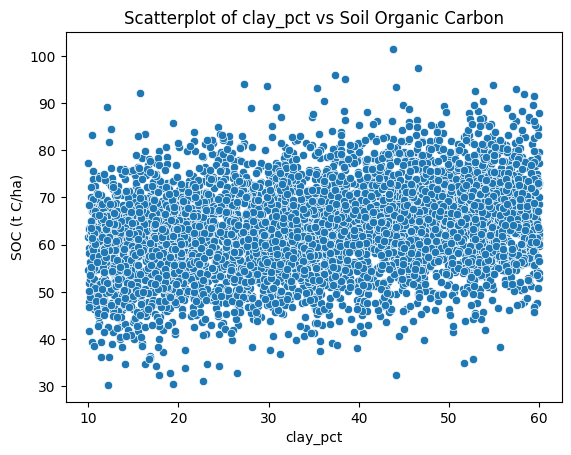

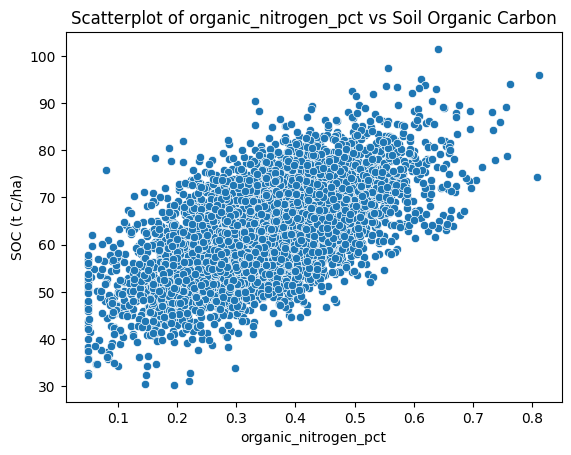

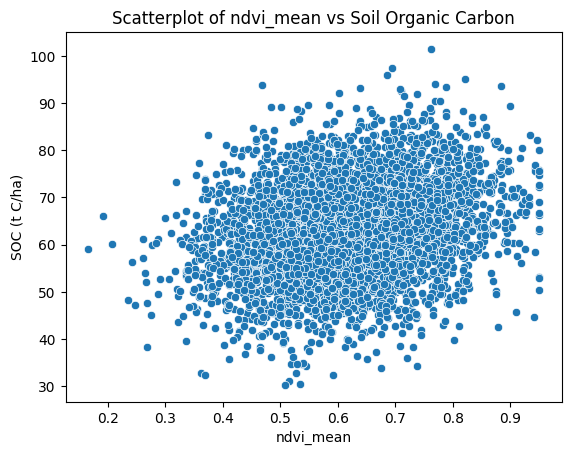

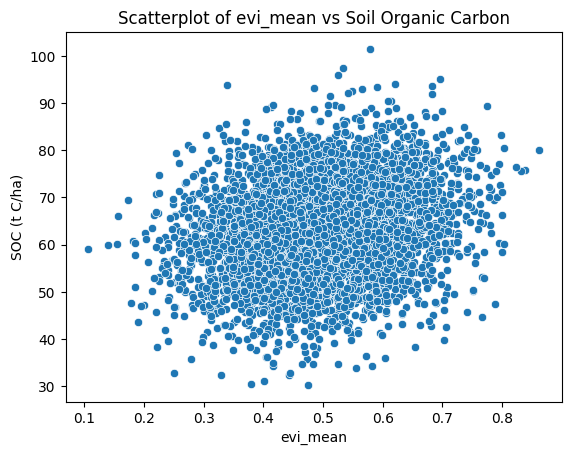

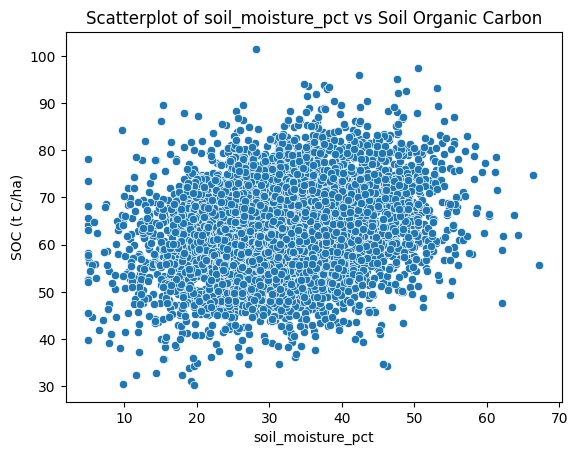

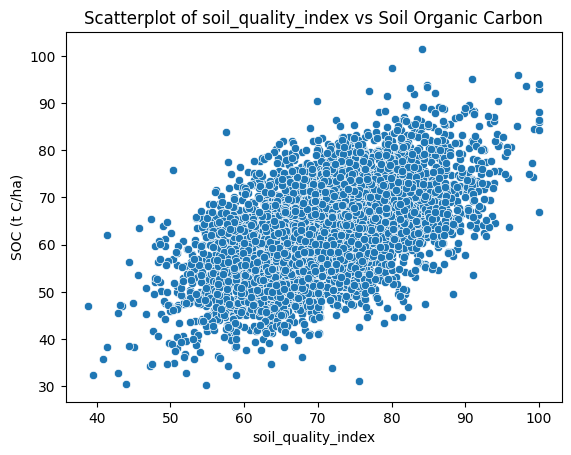

In [63]:
#Scatterplots
scatterplots = [
'topographic_wetness_index',
'annual_rainfall_mm',
'annual_temperature_c',
'summer_temperature_c',
'winter_temperature_c',
'drought_index',
'clay_pct',
'organic_nitrogen_pct',
'ndvi_mean',
'evi_mean',
'soil_moisture_pct',
'soil_quality_index',
]

for s in scatterplots:
    sns.scatterplot(
        x=df[s],
        y=df["soil_organic_carbon_target"]
    )
    plt.title(f"Scatterplot of {s} vs Soil Organic Carbon")
    plt.xlabel(s)
    plt.ylabel("SOC (t C/ha)")
    plt.show()

---
## Data Preprocessing

1. Remove Invalid Column
1. Test Train Validation split
1. Scale the data to aid neural network performance

In [76]:
# This line for testing should be commented out
df = pd.read_csv("../data/NZ_LUCAS_SMAP_NIWA.csv")
# Drop the unnecessary column '36' from the dataframe.
df.drop(columns=['36'], inplace=True)

# Target
y = df["soil_organic_carbon_target"]

# Features (Drop soil_organic_carbon_target from the features)
X = df.drop(columns=["soil_organic_carbon_target"])


# Train (70%) / Temp (30%)

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

# Validation (15%) / Test (15%)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

# Scale the data to aid neural network training.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)


#Verify the shapes of the training, validation, and test sets, as well as the mean and standard deviation of the scaled training set.
print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

print('X_train_scaled mean:', X_train_scaled.mean())
print('X_train_scaled standard deviation:', X_train_scaled.std())

Training set: (3500, 35)
Validation set: (750, 35)
Test set: (750, 35)
X_train_scaled mean: -5.977259503679863e-17
X_train_scaled standard deviation: 1.0
